# SI Figure 1
Temperature Latitude-Pressure Cross Section

Import statements

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

## File names

In [7]:
# Factual simulations
factual_namelist = [
    f"/glade/derecho/scratch/smhenry/neuralGCM/sims/factual/ensmean_JASO/{yr}_ensmean_JASO_factual_raw.nc"
    for yr in range(2004, 2023 + 1)
]

# Counterfactual simulations
counterfactual_namelist = [
    f"/glade/derecho/scratch/smhenry/neuralGCM/sims/counterfactual/ensmean_JASO/{yr}_ensmean_JASO_counterfactual_raw.nc"
    for yr in range(2004, 2023 + 1)
]

# NOAA 20th Century Reanalysis
NOAA_20thcentury_name = (
    "/glade/work/smhenry/NeuralGCM/data/NOAA_20thcentury/air.mon.mean.nc"
)

# ECMWF 20th Century Renalysis II
# ECMWF_20thcentury_name = ("/glade/work/smhenry/NeuralGCM/data/ECMWF_20thcentury/")

## Open data

In [8]:
factual_T = xr.concat(
    [xr.open_dataset(factual_namelist[i]) for i in range(len(factual_namelist))],
    dim="time",
).temperature.mean(dim="time")

counterfactual_T = xr.concat(
    [
        xr.open_dataset(counterfactual_namelist[i])
        for i in range(len(counterfactual_namelist))
    ],
    dim="time",
).temperature.mean(dim="time")

NOAA_T_past = (
    xr.open_dataset(NOAA_20thcentury_name)
    .air.sel(time=slice("1851-01", "1900-01"))
    .mean(dim="time")
)
NOAA_T_pres = (
    xr.open_dataset(NOAA_20thcentury_name)
    .air.sel(time=slice("1965-01", "2014-01"))
    .mean(dim="time")
)

# ECMWF_T_past = xr.open_dataset(ECMWF_20thcentury_name).VARIABLE.sel(time=slice("1851-01","1900-01")).mean(dim="time")
# ECMWF_T_pres = xr.open_dataset(ECMWF_20thcentury_name).VARIABLE.sel(time=slice("1965-01","2014-01")).mean(dim="time")

## Take longitudinal mean & differences

In [9]:
factual_T_cross = factual_T.mean(dim="longitude").sel(level=slice(100, 1000))
counterfactual_T_cross = counterfactual_T.mean(dim="longitude").sel(
    level=slice(100, 1000)
)
fmc_T_cross = factual_T_cross - counterfactual_T_cross

NOAA_T_past_cross = NOAA_T_past.mean(dim="lon").sel(level=slice(1000, 100))
NOAA_T_pres_cross = NOAA_T_pres.mean(dim="lon").sel(level=slice(1000, 100))
NOAA_T_diff_cross = NOAA_T_pres_cross - NOAA_T_past_cross

## Plot

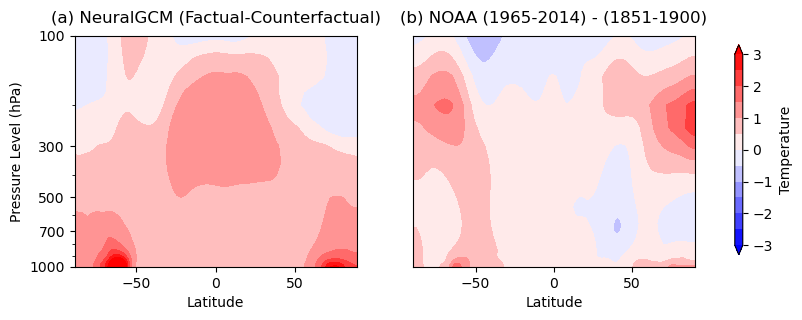

In [21]:
lat_list = [fmc_T_cross.latitude.values, NOAA_T_diff_cross.lat.values]
level_list = [fmc_T_cross.level.values, NOAA_T_diff_cross.level.values]
data_list = [fmc_T_cross, NOAA_T_diff_cross]
title_list = ["(a) NeuralGCM (Factual-Counterfactual)", "(b) NOAA (1965-2014) - (1851-1900)"]
yticks = [1000, 700, 500, 300, 100]
levels = np.linspace(-3, 3, num=13)

ncol = 2

fig, axs = plt.subplots(nrows=1,ncols=ncol,figsize=(8, 3))
axs = axs.flatten()

for i, ax in enumerate(axs):
    
    cf = ax.contourf(
        lat_list[i],
        level_list[i],
        data_list[i],
        cmap="bwr",
        levels=levels,
        extend="both",
    )
    
    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.set_xlabel("Latitude")

    if i == 0:
        # fix y axis
        ax.yaxis.set_minor_formatter(plt.NullFormatter())
        ax.set_yticks(yticks)
        ax.set_yticklabels([str(y) for y in yticks])
        
        ax.set_ylabel("Pressure Level (hPa)")
    else:
        ax.get_yaxis().set_visible(False)
        
    if i == len(axs)-1:
        cbar_ax = fig.add_axes([.95, 0.15, 0.01, 0.7])  # [left, bottom, width, height]
        cbar = plt.colorbar(cf, cax=cbar_ax)
        cbar.set_label("Temperature")
    
    ax.set_title(title_list[i], fontsize=12, pad=10)

# plt.suptitle("Latitude-Level Plot of Longitudinal Mean Temperature")
plt.savefig("./figs/SI_figure1.png", dpi=300, bbox_inches="tight")
plt.show()